# Sales Performance Analysis
Superstore Dataset (Kaggle) https://www.kaggle.com/datasets/vivek468/superstore-dataset-final/data

## Business Problem

The objective of this project is to analyze sales and profit performance
using the Superstore dataset. The goal is to identify key drivers of
revenue and profitability across product categories, regions, and time.

Key questions:
• Which categories generate the most revenue?
• Which regions are most profitable?
• How do sales and profits evolve over time?
• Which products drive the most sales?
• How does discounting affect profitability?

# Import Libraries

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

# Load Dataset

In [8]:
df = pd.read_csv(
    "/projects/sales-dashboard/data/Superstore.csv",
    encoding="ISO-8859-1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Data Cleaning

Before analysis we:
• convert date columns
• check missing values
• create additional features

In [47]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)

# KPI Overview

In [48]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009


## Sales by Category

This chart shows the total sales generated by each product category.

Technology is the leading category in terms of revenue, indicating strong demand for technology-related products. Furniture and Office Supplies also contribute significantly to overall sales, but their revenue levels are lower compared to Technology.

This suggests that technology products play a key role in driving overall business performance.

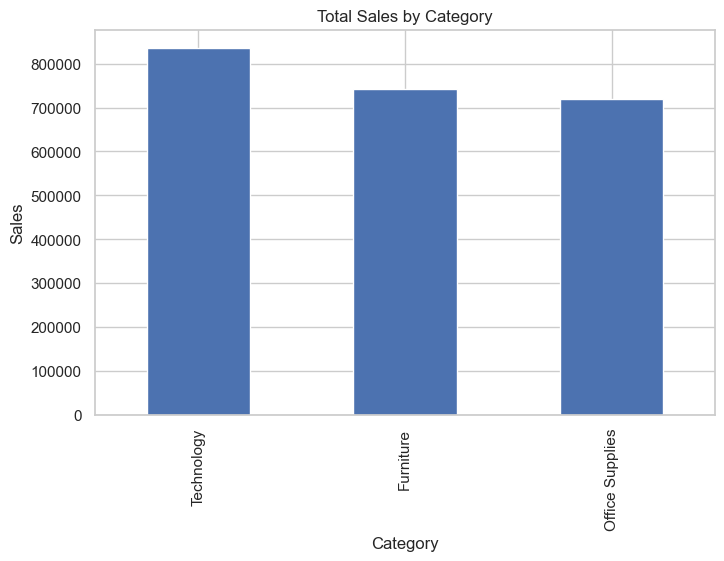

In [67]:
sales_by_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sales_by_category.plot(kind="bar")

plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")

plt.savefig("dashboard_images/sales_by_category.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Profit by Region

The profit distribution across regions reveals noticeable differences in performance.

The West region generates the highest profit, suggesting stronger market demand or more effective sales strategies in that region. Other regions contribute to overall profitability but at lower levels.

Understanding regional performance can help the company allocate resources more effectively and identify opportunities for market expansion.

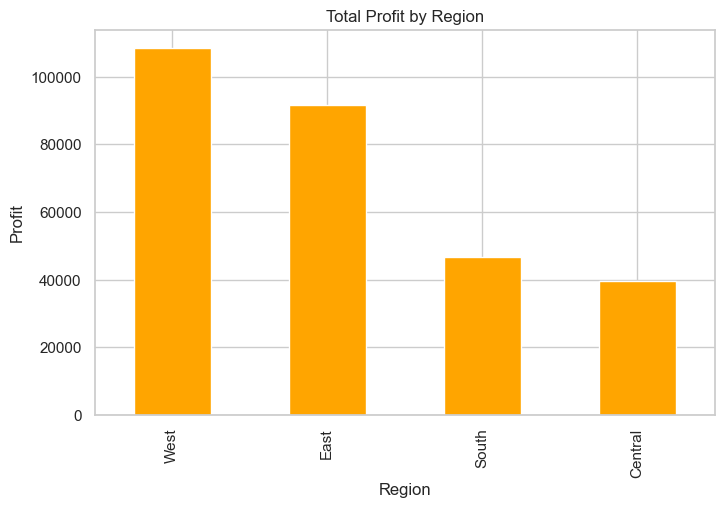

In [69]:
profit_by_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

profit_by_region.plot(kind="bar", color="orange")

plt.title("Total Profit by Region")
plt.ylabel("Profit")
plt.xlabel("Region")

plt.savefig("dashboard_images/profit_by_region.png", dpi=300, bbox_inches="tight")

plt.show()

## Monthly Sales Trend

The sales trend over time highlights fluctuations in monthly revenue.

Sales show periodic increases and decreases throughout the timeline, which may reflect seasonal demand patterns, promotional campaigns, or market dynamics. Peaks in sales indicate periods of strong business activity.

Tracking these trends helps businesses plan inventory, marketing campaigns, and sales strategies more effectively.

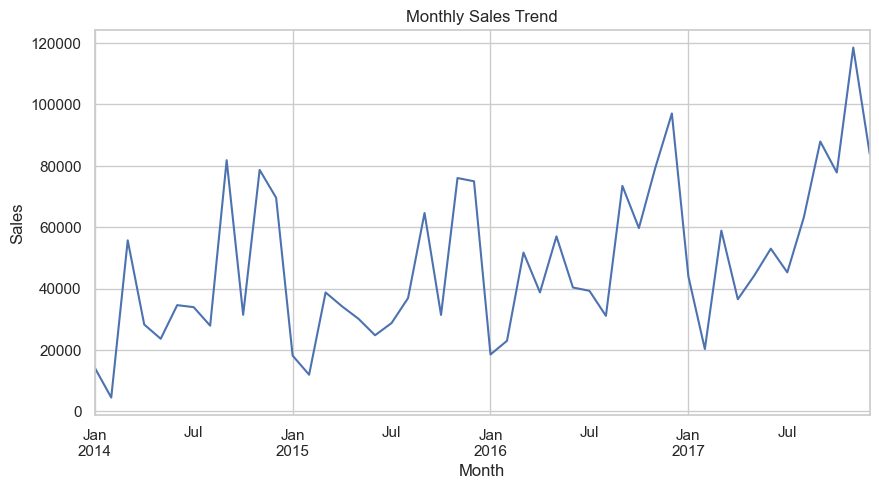

In [70]:
monthly_sales = (
    df.groupby("Order Month")["Sales"]
    .sum()
)

monthly_sales.index = pd.to_datetime(monthly_sales.index)

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.savefig("dashboard_images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

## Monthly Profit Trend

The profit trend generally follows the same pattern as the sales trend, indicating that higher sales often lead to higher profitability.

However, the relationship is not always proportional, which suggests that factors such as discounts, product mix, and operational costs may influence profit margins.

Analyzing profit trends alongside sales trends provides deeper insights into the company's financial performance.

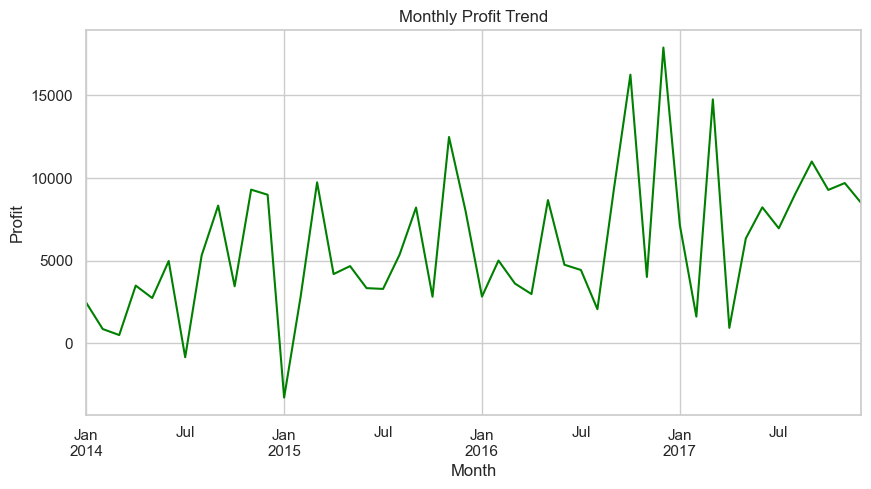

In [71]:
monthly_profit = (
    df.groupby("Order Month")["Profit"]
    .sum()
)

monthly_profit.index = pd.to_datetime(monthly_profit.index)

plt.figure(figsize=(10,5))

monthly_profit.plot(color="green")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.savefig("dashboard_images/monthly_profit_trend.png", dpi=300, bbox_inches="tight")

plt.show()

## Top 10 Products by Sales

This chart highlights the products that generate the highest sales.

A small number of products account for a large portion of total revenue. This indicates that the company relies heavily on a limited set of high-performing products.

Identifying these top-performing products is important for inventory management, marketing prioritization, and strategic product positioning.

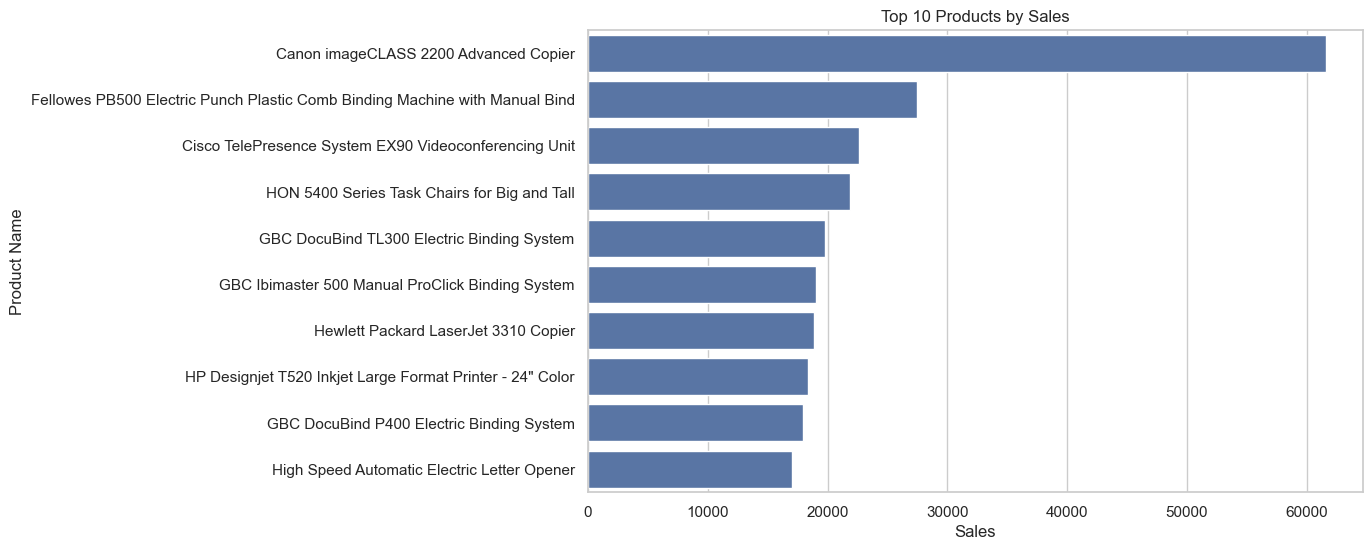

In [72]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.savefig("dashboard_images/top_products.png", dpi=300, bbox_inches="tight")

plt.show()

## Discount vs Profit

The relationship between discount and profit reveals a clear pattern.

Higher discount levels tend to be associated with lower profitability. In some cases, excessive discounting results in negative profit, meaning the company is selling products at a loss.

This insight suggests that discount strategies should be carefully managed to avoid eroding profit margins.

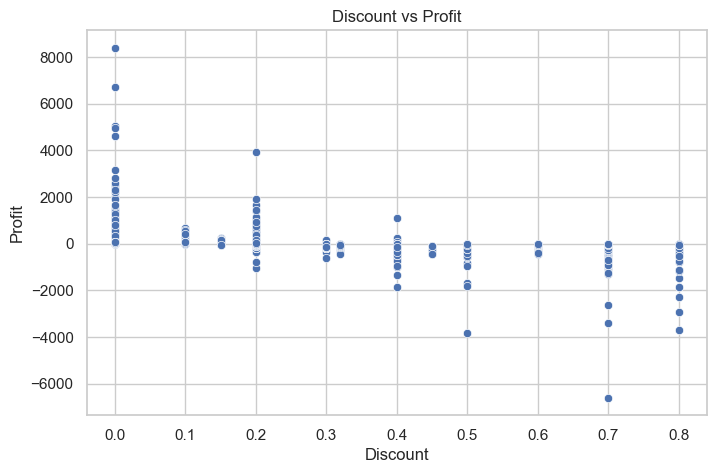

In [73]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Discount", y="Profit", data=df)

plt.title("Discount vs Profit")

plt.savefig("dashboard_images/discount_vs_profit.png", dpi=300, bbox_inches="tight")

plt.show()

## Key Insights

- Technology is the leading category in both sales and profit.
- The West region contributes the highest profitability.
- Sales and profits show seasonal fluctuations over time.
- A small number of products generate a large share of total revenue.
- Higher discount levels are often associated with lower profitability.

In [64]:
os.getcwd()

'/Users/anhdang/PycharmProjects/data-analyst-portfolio/projects/sales-dashboard'

In [65]:
import os
os.listdir()

['sales_dashboard_analysis.ipynb', 'dashboard_images', 'README.md', 'data']